# DATA586 Plot Notebook

Rubric-aligned order:
1. Baseline vs Custom model grouping
2. Clean test performance
3. Robustness on transformed test variants
4. Aggregate robustness
5. Performance vs Efficiency trade-off
6. Failure analysis (Confusion Matrix + Grad-CAM)


## Experiment Design Summary

This notebook discusses **10 models only**: 5 ResNet18 variants and 5 EfficientNet variants. The methods used in this study are limited to **Baseline (linear probe)**, **BN tuning**, **Unfreeze**, **LoRA**, and **TSA**.

Most configurations reached stable performance within the first 10 epochs. However, for safety, **each configuration was trained for 20 epochs**, and we report the **best checkpoint selected during training** in the comparisons below.

### ResNet18 Family: Layer Structure and Available Methods

| Layer | Main role | Input -> Output channels | Available methods for this layer |
| --- | --- | --- | --- |
| `input` | RGB image input | `3 -> 3` | None |
| `stem` | Initial convolution + normalization + spatial downsampling | `3 -> 64` | BN tuning, Unfreeze |
| `layer1` | Early residual feature extraction | `64 -> 64` | BN tuning, Unfreeze |
| `layer2` | Mid-level residual feature extraction | `64 -> 128` | BN tuning, Unfreeze |
| `layer3` | Higher-level semantic feature extraction | `128 -> 256` | BN tuning, Unfreeze, TSA |
| `layer4` | Final high-level semantic feature extraction | `256 -> 512` | BN tuning, Unfreeze, LoRA, TSA |
| `classifier (fc)` | Final classification head | `512 -> num_classes` | Baseline, BN tuning, Unfreeze, LoRA, TSA |
| `output` | Class logits | `num_classes -> num_classes` | None |

### EfficientNet Family: Layer Structure and Available Methods

| Layer | Main role | Input -> Output channels | Available methods for this layer |
| --- | --- | --- | --- |
| `input` | RGB image input | `3 -> 3` | None |
| `stem` | Initial convolutional stem | `3 -> 24` | BN tuning, Unfreeze |
| `features.0` | Early fused MBConv feature extraction | `24 -> 24` | BN tuning, Unfreeze |
| `features.1` | Early fused MBConv feature extraction + downsampling | `24 -> 48` | BN tuning, Unfreeze |
| `features.2` | Mid-level fused MBConv feature extraction | `48 -> 64` | BN tuning, Unfreeze |
| `features.3` | Mid-level MBConv feature extraction | `64 -> 128` | BN tuning, Unfreeze |
| `features.4` | Higher-level MBConv feature extraction | `128 -> 160` | BN tuning, Unfreeze |
| `features.5` | Late MBConv semantic feature extraction | `160 -> 256` | BN tuning, Unfreeze, TSA |
| `features.6` | Head convolution before pooling | `256 -> 1280` | BN tuning, Unfreeze, LoRA, TSA |
| `features.7` | Global pooling / final feature aggregation | `1280 -> 1280` | BN tuning, Unfreeze, LoRA, TSA |
| `classifier` | Final classification head | `1280 -> num_classes` | Baseline, BN tuning, Unfreeze, LoRA, TSA |
| `output` | Class logits | `num_classes -> num_classes` | None |

### ResNet18 Variants: Applied Adaptation Strategy

| Model | Adaptation strategy |
| --- | --- |
| `resnet18_baseline` | Linear probing: the backbone is frozen and only the final classifier (`fc`) is optimized. |
| `resnet18_bn_tuning` | BatchNorm tuning: BatchNorm parameters throughout the backbone are updated, while the classifier is also trained. |
| `resnet18_full_finetune` | Unfreeze training: all backbone layers and the classifier are unfrozen and jointly optimized. |
| `resnet18_lora` | LoRA adaptation: low-rank adapters are inserted into `layer4`, and the classifier is optimized jointly. |
| `resnet18_tsa` | TSA adaptation: task-specific adapter modules are inserted into `layer3` and `layer4`, with the classifier trained jointly. |

### EfficientNet Variants: Applied Adaptation Strategy

| Model | Adaptation strategy |
| --- | --- |
| `efficientnet_baseline` | Linear probing: the backbone is frozen and only the classifier is optimized. |
| `efficientnet_bn_tuning` | BatchNorm tuning: BatchNorm parameters across the network are updated, while the classifier is also trained. |
| `efficientnet_full_finetune` | Unfreeze training: all feature stages and the classifier are unfrozen and jointly optimized. |
| `efficientnet_lora` | LoRA adaptation: low-rank adapters are inserted into `features.6`, `features.7`, and the classifier. |
| `efficientnet_tsa` | TSA adaptation: task-specific adapter modules are inserted into `features.5`, `features.6`, `features.7`, and the classifier. |



In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

from workflow import (
    build_model_family_path_groups,
    build_split_analysis_from_paths,
    get_latest_workflow_runs,
    build_split_analysis_from_latest,
    show_model_epoch_dynamics_paginated_interactive,
    plot_val_accuracy_all_models_interactive,
    plot_final_test_accuracy_model_comparison_interactive,
    plot_test_split_comparison_interactive,
    plot_efficiency_compare_interactive,
    show_model_confusions_paginated_interactive,
    build_model_specs_from_latest_df,
    sample_test_split_images,
    show_gradcam_compare,
    show_workflow_summary_table,
    print_rubric_summary,
)

PROJECT_ROOT = Path.cwd()


## Runtime Safety (recommended)
Use CPU-first and keep heavy visualization off unless needed.


In [2]:
# Safety toggles
SAFE_DEVICE = 'cpu'
RUN_HEAVY_VIS = False  # turn True only when needed

print(f'SAFE_DEVICE={SAFE_DEVICE}, RUN_HEAVY_VIS={RUN_HEAVY_VIS}')


SAFE_DEVICE=cpu, RUN_HEAVY_VIS=False


## Step 1) Import all training logs (workflow)


In [3]:
runs_df, latest_df = get_latest_workflow_runs()
MODEL_FAMILY_ORDER = ["ResNet18", "EfficientNet"]
model_groups = build_model_family_path_groups(latest_df)
latest_df[[
    "generated_at_utc", "model_name", "model_type", "best_eval_acc", "final_test_acc", "clean_accuracy", "robustness_average", "path"
]]


Total workflow runs: 10
Latest unique models: 10


,generated_at_utc,model_name,model_type,best_eval_acc,final_test_acc,clean_accuracy,robustness_average,path
0,2026-04-07T16:54:49+00:00,efficientnet_full_finetune,Custom,0.741122,0.782772,0.782574,0.539976,C:\Users\18447\DATA586Project\logs\workflow_ru...
1,2026-04-07T13:53:03+00:00,resnet18_full_finetune,Custom,0.578218,0.606812,0.622812,0.423366,C:\Users\18447\DATA586Project\logs\workflow_ru...
2,2026-04-07T12:41:59+00:00,efficientnet_bn_tuning,Custom,0.793663,0.841386,0.838614,0.685933,C:\Users\18447\DATA586Project\logs\workflow_ru...
3,2026-04-07T10:22:12+00:00,resnet18_bn_tuning,Custom,0.631419,0.677188,0.672634,0.493766,C:\Users\18447\DATA586Project\logs\workflow_ru...
4,2026-04-07T09:21:01+00:00,efficientnet_tsa,Custom,0.693729,0.732634,0.730099,0.565141,C:\Users\18447\DATA586Project\logs\workflow_ru...
5,2026-04-07T05:17:13+00:00,resnet18_tsa,Custom,0.640528,0.661426,0.686574,0.531469,C:\Users\18447\DATA586Project\logs\workflow_ru...
6,2026-04-07T04:12:06+00:00,efficientnet_lora,Custom,0.645149,0.658931,0.687802,0.535778,C:\Users\18447\DATA586Project\logs\workflow_ru...
7,2026-04-07T02:16:33+00:00,resnet18_lora,Custom,0.501518,0.534337,0.533347,0.398440,C:\Users\18447\DATA586Project\logs\workflow_ru...
8,2026-04-07T01:17:06+00:00,efficientnet_baseline,Baseline (linear probe),0.483168,0.515327,0.521584,0.363651,C:\Users\18447\DATA586Project\logs\workflow_ru...
9,2026-04-06T23:55:38+00:00,resnet18_baseline,Baseline (linear probe),0.512079,0.549069,0.544911,0.378257,C:\Users\18447\DATA586Project\logs\workflow_ru...


## Step 2) Baseline vs Custom summary table


In [4]:
for family_label in MODEL_FAMILY_ORDER:
    group = model_groups[family_label]
    display(Markdown(f"### {family_label} ({len(group['latest_df'])} experiments)"))
    _ = show_workflow_summary_table(group["workflow_summary_paths"])


### ResNet18 (5 experiments)

,Model,Best Eval,Final Test,Clean,Robustness Avg,Trainable Params
0,resnet18_baseline,0.5121,0.5491,0.5449,0.3783,"51,813"
1,resnet18_bn_tuning,0.6314,0.6772,0.6726,0.4938,"61,413"
2,resnet18_full_finetune,0.5782,0.6068,0.6228,0.4234,"11,228,325"
3,resnet18_lora,0.5015,0.5343,0.5333,0.3984,"23,336"
4,resnet18_tsa,0.6405,0.6614,0.6866,0.5315,"379,493"


### EfficientNet (5 experiments)

,Model,Best Eval,Final Test,Clean,Robustness Avg,Trainable Params
0,efficientnet_baseline,0.4832,0.5153,0.5216,0.3637,"129,381"
1,efficientnet_bn_tuning,0.7937,0.8414,0.8386,0.6859,"283,253"
2,efficientnet_full_finetune,0.7411,0.7828,0.7826,0.5400,"20,306,869"
3,efficientnet_lora,0.6451,0.6589,0.6878,0.5358,"594,152"
4,efficientnet_tsa,0.6937,0.7326,0.7301,0.5651,"994,149"


## Step 3) Clean test performance / Robustness per variant / Aggregate robustness


In [5]:
analysis = build_split_analysis_from_latest(latest_df, show_tables=False)
analysis_by_family = {}
for family_label in MODEL_FAMILY_ORDER:
    group = model_groups[family_label]
    display(Markdown(f"### {family_label} ({len(group['latest_df'])} experiments)"))
    family_analysis = build_split_analysis_from_paths(
        group["test_split_json_paths"],
        latest_df=group["latest_df"],
        show_tables=True,
    )
    analysis_by_family[family_label] = family_analysis
test_split_json_paths = analysis["test_split_json_paths"]
split_df = analysis["split_df"]
clean_and_agg_df = analysis["clean_and_agg_df"]
variant_df = analysis["variant_df"]


### ResNet18 (5 experiments)

Model Summary + Robustness by Variant


,model_name,model_type,clean_accuracy,robustness_average,total_seconds,split::blur_little,split::blur_medium,split::clean,split::downsampled,split::masked,split::noise_rotation
4,resnet18_tsa,Custom,0.686574,0.531469,1001.388090,0.621069,0.480594,0.686574,0.307248,0.632475,0.615960
1,resnet18_bn_tuning,Custom,0.672634,0.493766,857.312682,0.595604,0.409228,0.672634,0.241109,0.621861,0.601030
2,resnet18_full_finetune,Custom,0.622812,0.423366,797.185353,0.518970,0.281901,0.622812,0.164238,0.587050,0.564673
0,resnet18_baseline,Baseline (linear probe),0.544911,0.378257,911.239619,0.459802,0.327564,0.544911,0.168950,0.466139,0.468832
3,resnet18_lora,Custom,0.533347,0.398440,957.462523,0.470931,0.345069,0.533347,0.217703,0.486891,0.471604


### EfficientNet (5 experiments)

Model Summary + Robustness by Variant


,model_name,model_type,clean_accuracy,robustness_average,total_seconds,split::blur_little,split::blur_medium,split::clean,split::downsampled,split::masked,split::noise_rotation
1,efficientnet_bn_tuning,Custom,0.838614,0.685933,873.228949,0.786931,0.643921,0.838614,0.366693,0.829069,0.803050
2,efficientnet_full_finetune,Custom,0.782574,0.539976,1018.527231,0.680000,0.379366,0.782574,0.177109,0.756436,0.706970
4,efficientnet_tsa,Custom,0.730099,0.565141,927.371165,0.653307,0.490139,0.730099,0.278733,0.713663,0.689861
3,efficientnet_lora,Custom,0.687802,0.535778,1036.566932,0.614535,0.472871,0.687802,0.273545,0.671564,0.646376
0,efficientnet_baseline,Baseline (linear probe),0.521584,0.363651,1004.271070,0.411604,0.274099,0.521584,0.146535,0.501267,0.484752


## Step 3.5) Epoch Dynamics + Final Test Comparison


In [6]:
training_log_paths = [p for p in latest_df["training_run_log"].dropna().tolist() if Path(str(p)).exists()]
_ = show_model_epoch_dynamics_paginated_interactive(training_log_paths, max_epochs=20, page_size=1)
for family_label in MODEL_FAMILY_ORDER:
    family_training_log_paths = model_groups[family_label]["training_log_paths"]
    display(Markdown(f"### {family_label} ({len(family_training_log_paths)} experiments)"))
    _ = plot_val_accuracy_all_models_interactive(family_training_log_paths, max_epochs=20)
    _ = plot_final_test_accuracy_model_comparison_interactive(family_training_log_paths)


### ResNet18 (5 experiments)

### EfficientNet (5 experiments)

#### ResNet18 Robustness

Within the ResNet18 family, TSA shows the strongest robustness overall. It has the highest clean accuracy (0.6866) and the highest robustness average (0.5315), and it performs best across all corrupted splits, including blur_little, blur_medium, downsampled, masked, and noise_rotation. BN tuning is the second-best option, but it falls behind TSA more clearly on the harder corruptions, especially blur_medium and downsampled, suggesting that its robustness gains on ResNet18 are more limited. Full fine-tuning performs worse under distribution shift despite reasonable clean accuracy, while LoRA remains weak overall, though it is slightly more robust than the baseline on some harder corrupted splits.

#### EfficientNet Robustness

Comparing the two backbones, EfficientNet is clearly more robust overall than ResNet18, with much higher clean accuracy and robustness scores. However, the best lightweight adaptation method is not the same for both architectures: BN tuning is the strongest method on EfficientNet, while TSA is the strongest on ResNet18. This suggests that the effectiveness of a PEFT method depends strongly on the backbone rather than transferring uniformly across architectures. Another consistent pattern is that full fine-tuning is not the most robust option on either backbone, which implies that lightweight adaptation can sometimes preserve pretrained representations more effectively under corruption.

#### Corruption Pattern Analysis

Across all models, the hardest corruption is clearly downsampled, followed by blur_medium. This indicates that Food-101 robustness depends heavily on preserving fine visual detail, which is especially important for distinguishing visually similar dishes. In contrast, masked and noise_rotation are generally less damaging, meaning that the models can often still classify correctly as long as enough of the main food region remains visible. Overall, the robustness bottleneck in this task is driven more by detail-destroying corruptions than by moderate occlusion or rotation-related noise.

## Step 4) Visualization: test variant comparison (workflow)


In [7]:
for family_label in MODEL_FAMILY_ORDER:
    family_test_split_json_paths = model_groups[family_label]["test_split_json_paths"]
    display(Markdown(f"### {family_label} ({len(family_test_split_json_paths)} experiments)"))
    _ = plot_test_split_comparison_interactive(family_test_split_json_paths)


### ResNet18 (5 experiments)

### EfficientNet (5 experiments)

## Step 5) Visualization: performance-efficiency trade-offs (workflow)


In [8]:
training_log_paths = [p for p in latest_df["training_run_log"].dropna().tolist() if Path(str(p)).exists()]
for family_label in MODEL_FAMILY_ORDER:
    family_training_log_paths = model_groups[family_label]["training_log_paths"]
    display(Markdown(f"### {family_label} ({len(family_training_log_paths)} experiments)"))
    _ = plot_efficiency_compare_interactive(family_training_log_paths)


### ResNet18 (5 experiments)

### EfficientNet (5 experiments)

#### ResNet18 accuracy and efficiency trade-off

For the five ResNet18 experiments, BN tuning appears to provide the best overall trade-off between accuracy and efficiency: it achieves the highest accuracy while keeping both training time and trainable parameters relatively low. TSA is the next strongest option, with slightly lower accuracy but still good efficiency, although its inference speed is somewhat slower. In contrast, full fine-tuning uses by far the largest number of trainable parameters and requires the longest training time, yet its accuracy is still below BN tuning and TSA, suggesting that updating all parameters is not the most cost-effective strategy in this setting. LoRA performs the worst overall, with the lowest accuracy despite having low training cost, while the baseline remains more balanced but clearly less competitive than the best PEFT methods. Overall, these results suggest that for ResNet18 on this task, lightweight adaptation methods—especially BN tuning—are more effective than full fine-tuning.

#### EfficientNet accuracy and efficiency trade-off

For the five EfficientNet experiments, BN tuning is clearly the strongest overall method, achieving the highest accuracy while still keeping the number of trainable parameters very low and maintaining one of the fastest inference speeds, which makes it both effective and efficient. TSA also performs well as a lighter alternative, reaching solid accuracy with relatively low training cost, although it still falls noticeably behind BN tuning. Full fine-tuning achieves competitive accuracy, but it is much more expensive in practice because it requires by far the largest number of trainable parameters and the longest training time, so its performance gain is not efficient relative to its cost. LoRA improves substantially over the baseline, but it is still clearly weaker than BN tuning, TSA, and full fine-tuning, while also having the slowest inference among the five methods. Overall, these results suggest that for EfficientNet on this task, BN tuning provides the best balance of accuracy, parameter efficiency, training cost, and deployment speed.

## Step 6) Failure analysis: confusion matrix (workflow)


In [9]:
show_model_confusions_paginated_interactive(latest_df, top_k=10, page_size=1)


#### ResNet18 Mistake Pattern

For the ResNet18 models, the overall pattern is fairly consistent: full fine-tuning and BN tuning perform the most reliably, TSA is in the middle, the baseline is reasonable but limited, and LoRA is the weakest. The baseline already handles visually distinctive classes such as takoyaki and garlic_bread fairly well, but it struggles once the task becomes more fine-grained. BN tuning improves class boundaries noticeably and produces cleaner confusion patterns, although difficult meat-based pairs such as steak, filet_mignon, and pork_chop are still repeatedly confused. TSA is more stable than LoRA, while LoRA shows the noisiest behavior and seems more vulnerable to superficial cues such as color, plating, or background. Full fine-tuning gives the strongest overall ResNet18 results, but even there, closely related main-dish categories remain a persistent challenge.

#### EfficientNet Mistake Pattern

For the EfficientNet models, the ranking is similar but even more pronounced: BN tuning and full fine-tuning are the strongest, TSA is moderate, the baseline is decent, and LoRA performs the worst. EfficientNet BN tuning is especially notable because it handles several hard pairs more cleanly than expected, including visually similar meat dishes such as steak and filet_mignon. The baseline captures many broad visual patterns well, but still confuses fine-grained dessert and entrée categories. TSA improves stability compared with LoRA, but it does not reach the same level of separation as BN tuning. Full fine-tuning raises the overall ceiling further, yet even this strongest variant still shows clear confusion inside clusters of similar dishes, especially among meat-based entrées.

#### Conclusion

Across both backbones, the shared pattern is very clear: the main difficulty is not broad category recognition, but fine-grained separation between visually similar dishes. The same confusion groups appear repeatedly, especially among meat dishes like steak, filet_mignon, pork_chop, and foie_gras, as well as dessert groups such as apple_pie, bread_pudding, and french_toast, or chocolate_mousse and chocolate_cake. Another common finding is that BN tuning is the most consistently strong lightweight adaptation method, while LoRA is the least stable and is more easily distracted by non-semantic visual cues. Full fine-tuning improves overall accuracy, but it does not eliminate hard pairs, which suggests that these errors reflect the intrinsic fine-grained nature of Food-101 rather than simple model weakness.

## Step 7) Failure analysis: Grad-CAM compare (workflow)


,split,image_path,class_name,filename
0,clean,C:\Users\18447\DATA586Project\data\test_splits...,red_velvet_cake,3749302.jpg
1,blur_little,C:\Users\18447\DATA586Project\data\test_splits...,carrot_cake,3175778.jpg
2,blur_medium,C:\Users\18447\DATA586Project\data\test_splits...,beef_carpaccio,1864287.jpg
3,downsampled,C:\Users\18447\DATA586Project\data\test_splits...,takoyaki,1615290.jpg
4,masked,C:\Users\18447\DATA586Project\data\test_splits...,falafel,125492.jpg
5,noise_rotation,C:\Users\18447\DATA586Project\data\test_splits...,dumplings,1343111.jpg


## ResNet18 Grad-CAM (5 models x 6 split samples)

### clean | red_velvet_cake | 3749302.jpg


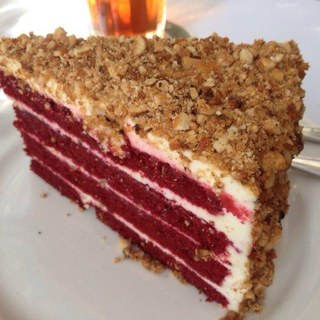
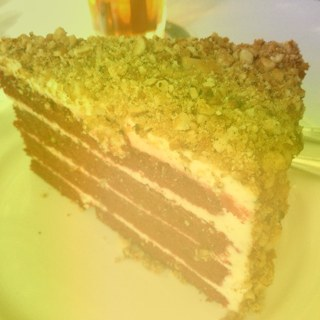
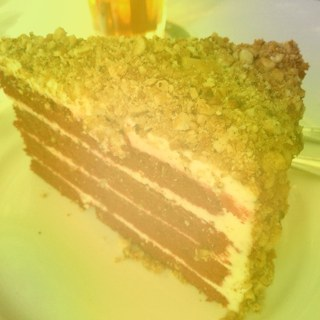
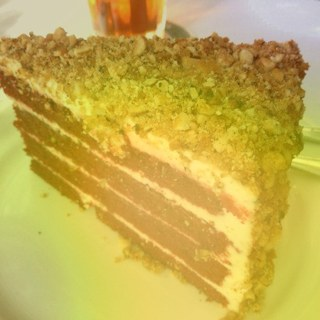
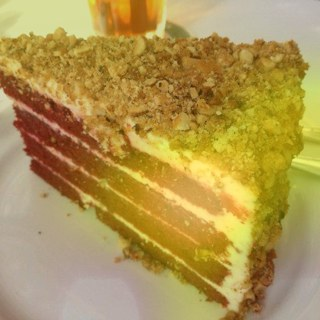
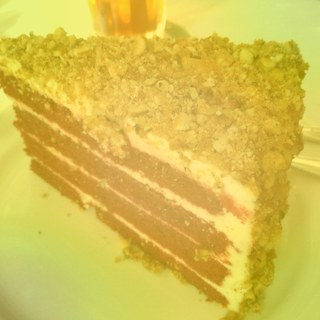

### blur_little | carrot_cake | 3175778.jpg


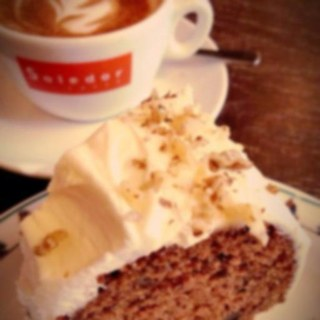
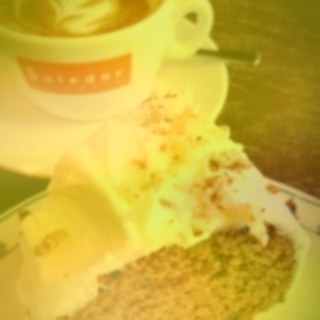
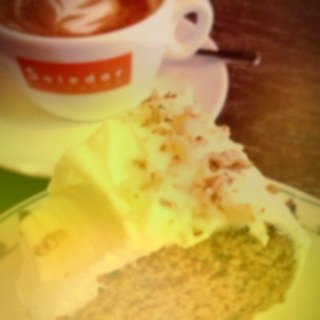
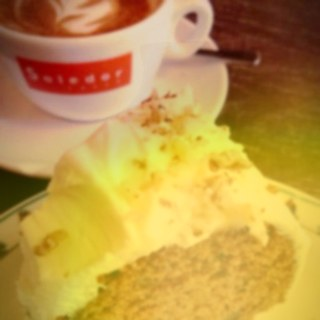
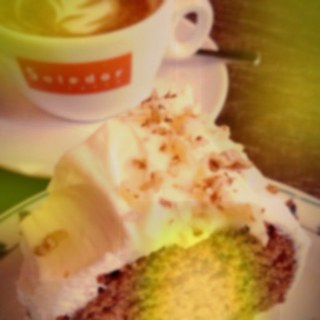
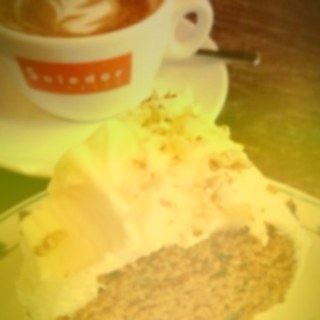

### blur_medium | beef_carpaccio | 1864287.jpg


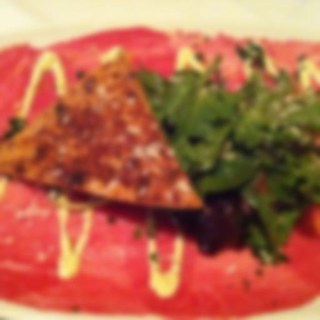
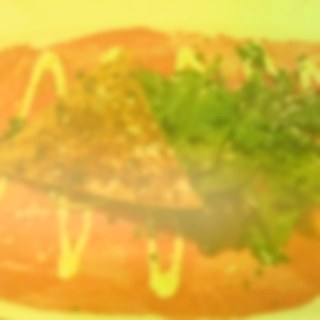
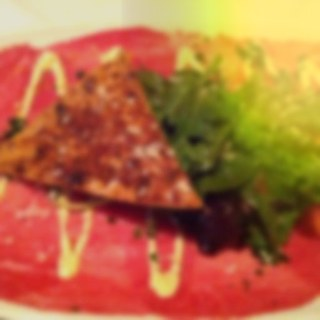
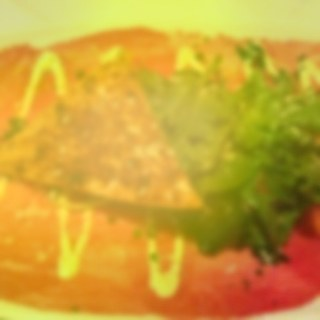
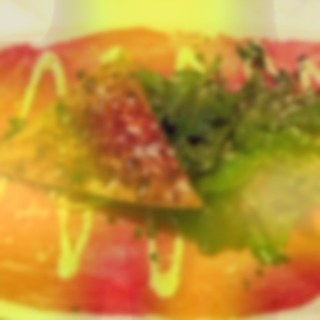
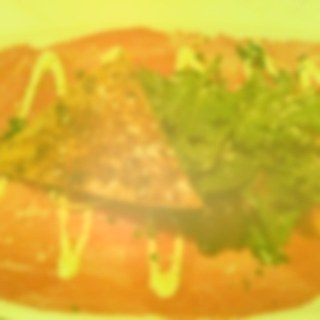

### downsampled | takoyaki | 1615290.jpg

### masked | falafel | 125492.jpg


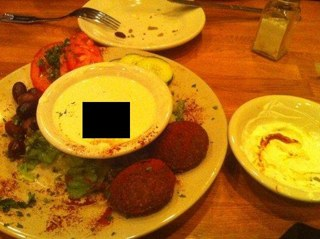
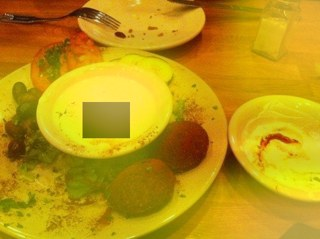
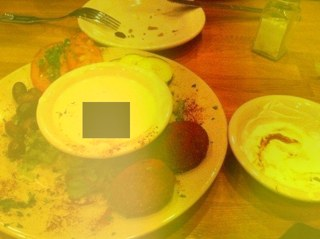
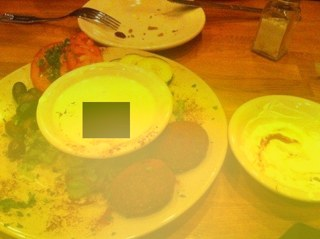
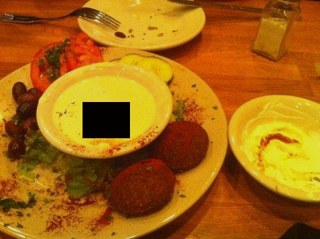
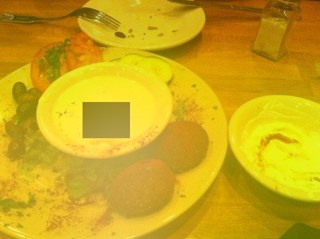

### noise_rotation | dumplings | 1343111.jpg


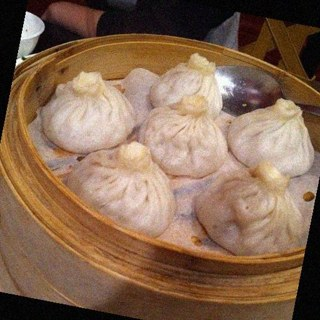
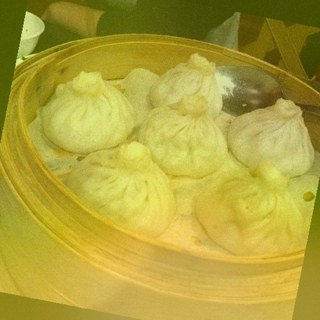
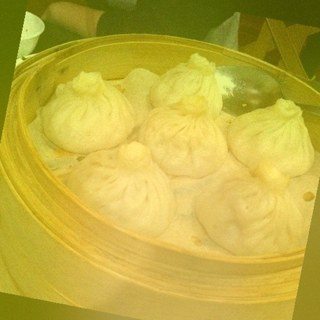
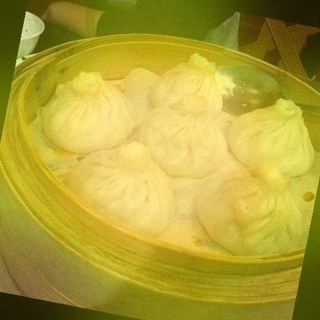
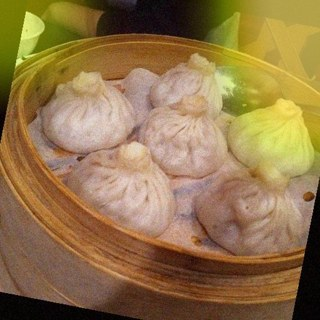
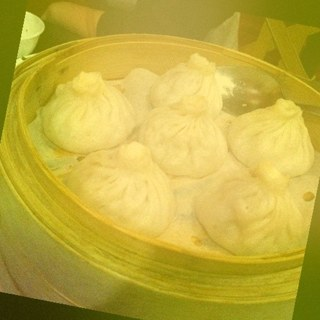

## EfficientNet Grad-CAM (5 models x 6 split samples)

### clean | red_velvet_cake | 3749302.jpg


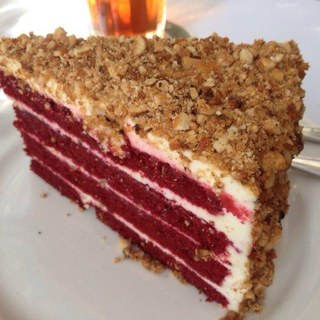
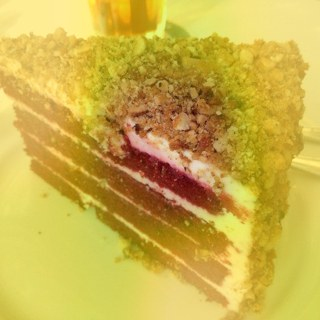
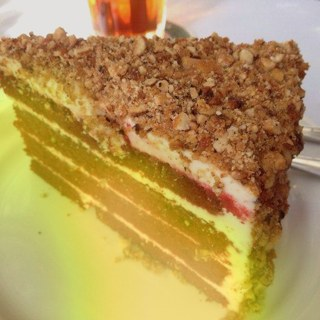
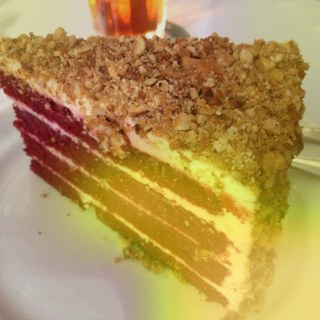
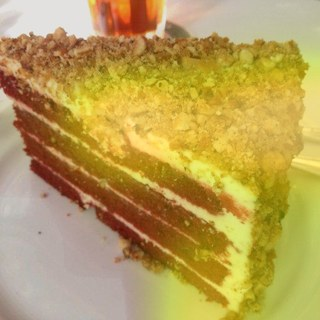
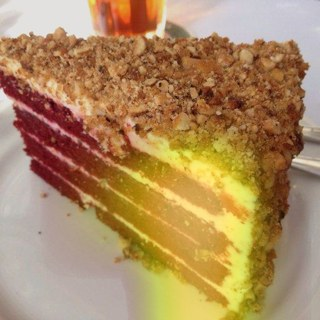

### blur_little | carrot_cake | 3175778.jpg


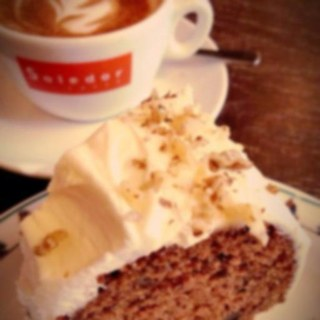
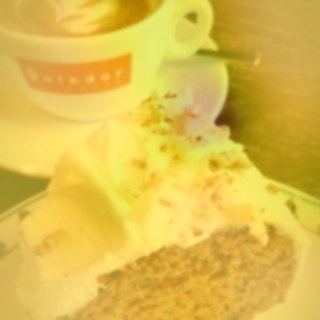
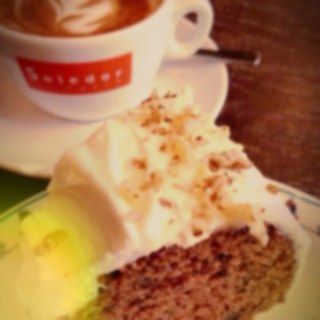
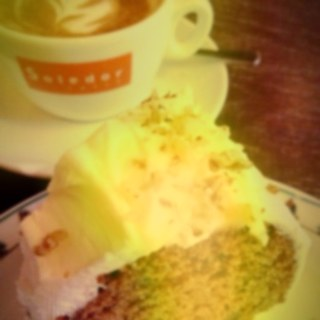
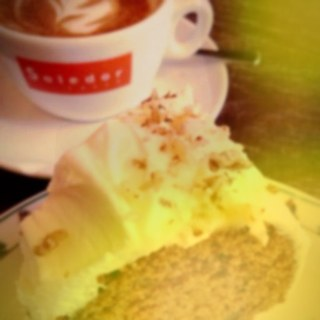
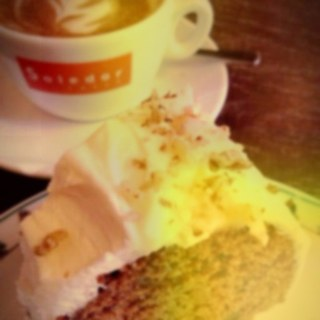

### blur_medium | beef_carpaccio | 1864287.jpg


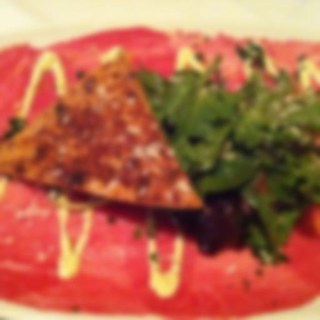
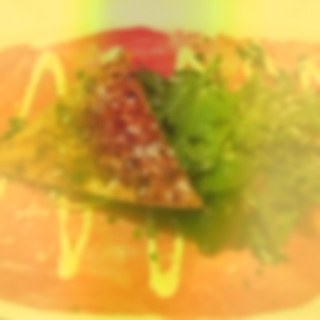
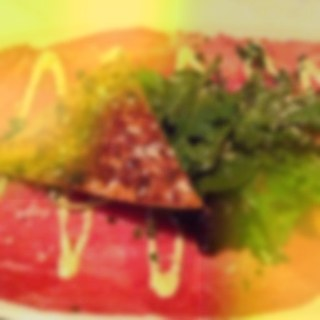
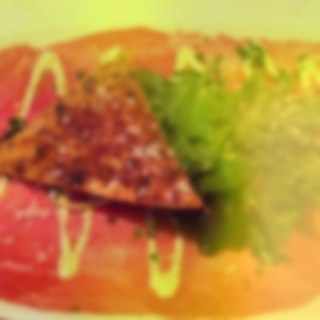
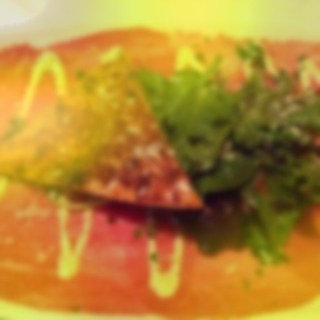
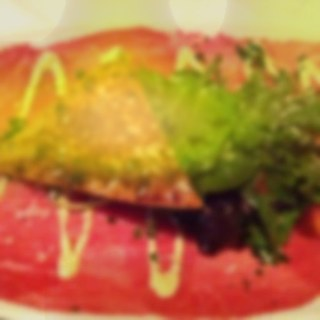

### downsampled | takoyaki | 1615290.jpg

### masked | falafel | 125492.jpg


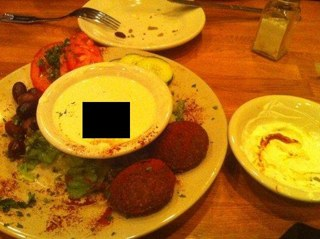
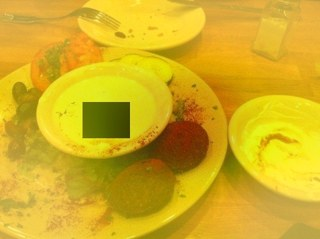
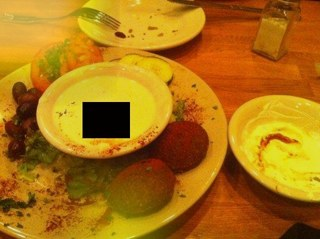
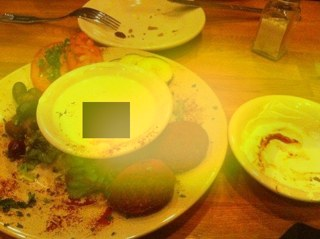
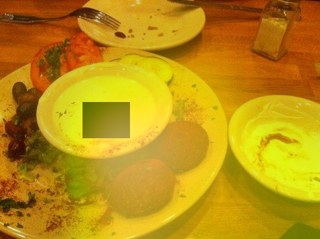
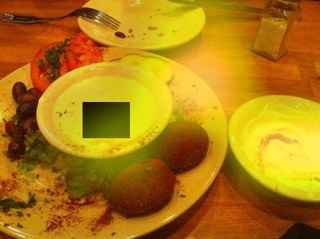

### noise_rotation | dumplings | 1343111.jpg


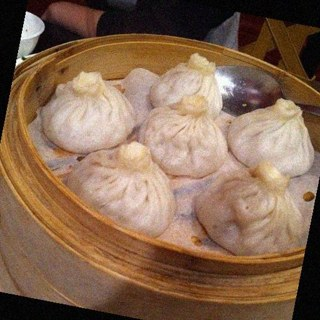
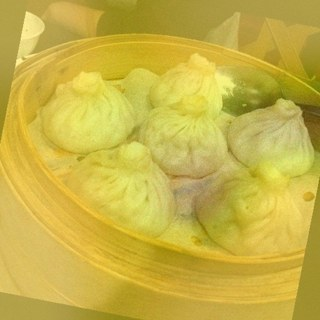
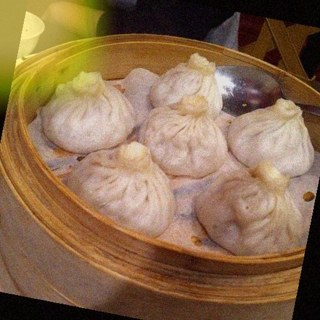
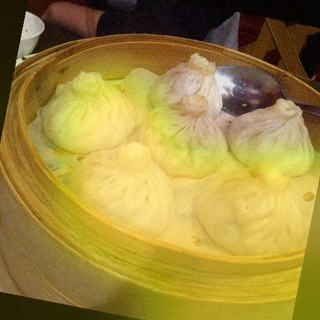
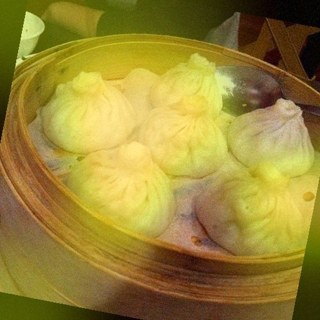
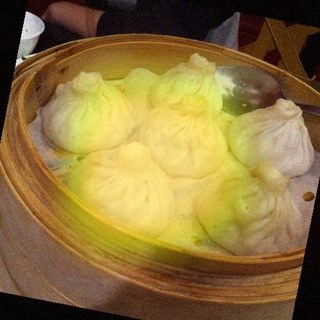

In [10]:
# Step 7: Grad-CAM compare by model family and test split sample
TEST_SPLIT_ROOT = PROJECT_ROOT / "data" / "test_splits"
gradcam_samples = sample_test_split_images(TEST_SPLIT_ROOT, seed=42)
display(pd.DataFrame(gradcam_samples))

for family_label in MODEL_FAMILY_ORDER:
    family_latest_df = model_groups[family_label]["latest_df"]
    family_model_specs = build_model_specs_from_latest_df(family_latest_df)
    display(Markdown(f"## {family_label} Grad-CAM ({len(family_model_specs)} models x {len(gradcam_samples)} split samples)"))
    for sample in gradcam_samples:
        split_name = sample["split"]
        class_name = sample["class_name"]
        image_path = sample["image_path"]
        filename = sample["filename"]
        display(Markdown(f"### {split_name} | {class_name} | {filename}"))
        show_gradcam_compare(
            image_path=image_path,
            model_specs=family_model_specs,
            image_size=128,
            device="cpu",
        )


### ResNet18 Grad-CAM Focus Patterns

1. The baseline model generally distributes its attention across most of the image, suggesting a broad and relatively non-selective focus pattern.

2. The BN-tuning model shows a stronger tendency to focus on the food region itself. However, its attention is still not tightly localized, as it often captures either too much or too little of the actual dish.

3. The full fine-tuning model demonstrates more accurate localization of the food compared with BN-tuning, indicating a clearer and more task-relevant focus pattern.

4. The LoRA model frequently concentrates on the corners of the image, suggesting that it sometimes fails to identify the main food region altogether.

5. The TSA model exhibits a focus pattern somewhat similar to the baseline. Although it attempts to attend to the food, its activation maps often include a substantial amount of background information.

### EfficientNet Grad-CAM Focus Patterns

1. The baseline model displays an unusual attention pattern: it often covers most of the image while leaving a relatively inactive region near the center, creating a “blind spot” effect.

2. The BN-tuning model tends to focus on image corners, which can make food localization unreliable in some cases. Despite this limitation, it achieves the highest classification accuracy among the EfficientNet variants.

3. The full fine-tuning model is generally able to attend to the food region, but its focus is often limited to only part of the dish. For example, it may attend primarily to the salad next to a steak and consequently classify the entire dish as salad.

4. The LoRA model also tends to activate on image corners. However, compared with the ResNet18 LoRA model, it more often includes portions of the actual food region, which may explain its slightly better predictive performance.

5. The TSA model shows a focus pattern similar to full fine-tuning, often attending to only part of the food. However, its activation is more frequently centered on the main food item, which may help improve prediction accuracy in some cases.

## Step 8) Auto-generated report text (ordered as rubric)


In [11]:
print_rubric_summary(clean_and_agg_df, variant_df)


[1] Performance on clean test set
- Baseline best: resnet18_baseline | clean_accuracy=0.5449
- Custom best:   efficientnet_bn_tuning | clean_accuracy=0.8386

[2] Robustness scores on each test set variant


,model_name,model_type,split::blur_little,split::blur_medium,split::clean,split::downsampled,split::masked,split::noise_rotation
8,efficientnet_baseline,Baseline (linear probe),0.411604,0.274099,0.521584,0.146535,0.501267,0.484752
2,efficientnet_bn_tuning,Custom,0.786931,0.643921,0.838614,0.366693,0.829069,0.803050
0,efficientnet_full_finetune,Custom,0.680000,0.379366,0.782574,0.177109,0.756436,0.706970
6,efficientnet_lora,Custom,0.614535,0.472871,0.687802,0.273545,0.671564,0.646376
4,efficientnet_tsa,Custom,0.653307,0.490139,0.730099,0.278733,0.713663,0.689861
9,resnet18_baseline,Baseline (linear probe),0.459802,0.327564,0.544911,0.168950,0.466139,0.468832
3,resnet18_bn_tuning,Custom,0.595604,0.409228,0.672634,0.241109,0.621861,0.601030
1,resnet18_full_finetune,Custom,0.518970,0.281901,0.622812,0.164238,0.587050,0.564673
7,resnet18_lora,Custom,0.470931,0.345069,0.533347,0.217703,0.486891,0.471604
5,resnet18_tsa,Custom,0.621069,0.480594,0.686574,0.307248,0.632475,0.615960



[3] Aggregate robustness


,model_name,model_type,robustness_average
2,efficientnet_bn_tuning,Custom,0.685933
4,efficientnet_tsa,Custom,0.565141
0,efficientnet_full_finetune,Custom,0.539976
6,efficientnet_lora,Custom,0.535778
5,resnet18_tsa,Custom,0.531469
3,resnet18_bn_tuning,Custom,0.493766
1,resnet18_full_finetune,Custom,0.423366
7,resnet18_lora,Custom,0.398440
9,resnet18_baseline,Baseline (linear probe),0.378257
8,efficientnet_baseline,Baseline (linear probe),0.363651



[4] Trade-off plots
- See Step 5: performance vs wall time / trainable params / inference speed

[5] Failure interpretation checklist
- Use Step 6 confusion matrices to identify dominant confusions
- Use Step 7 Grad-CAM to compare attention regions across model types
- Explain which transformed variants cause the largest accuracy drops


## Conclusion

Overall, the experiments show that Food-101 is mainly a fine-grained classification task, where the hardest errors come from visually similar dishes rather than broad category recognition. Across both ResNet18 and EfficientNet, the same confusion groups appeared repeatedly, especially among similar meat dishes and desserts, which suggests that these errors reflect the intrinsic difficulty of the dataset. Among the two backbones, EfficientNet consistently achieved stronger overall performance on both clean and corrupted data.

Across adaptation methods, BN tuning provided the best overall balance, especially on EfficientNet, where it achieved the strongest clean accuracy, the best robustness, and relatively reasonable confusion patterns. TSA was also effective, particularly for ResNet18, while LoRA was generally the weakest and least stable method. Although full fine-tuning improved overall classification in some cases, it was not the most robust option and still struggled with the hardest fine-grained pairs.

The Grad-CAM results further suggest that higher accuracy does not always mean better localization. Many models focused on the food region, but often either too broadly or too narrowly, which indicates that part of the performance may come from partial evidence or superficial visual cues. Overall, the main challenge is not just model capacity, but learning stable and semantically meaningful fine-grained representations.

## Bonus Follow-up Study (Paper-style Storyline)

### 1) Motivation: BN tuning is strong, but downsample remains the bottleneck

From the main EfficientNet experiments, **BN tuning** is already a strong baseline.  
However, its `downsampled` split accuracy is only **0.3667**, which is the main robustness weakness.

| Model | Clean | Robustness Avg | Downsampled |
| --- | ---: | ---: | ---: |
| `efficientnet_bn_tuning` | 0.8386 | 0.6859 | 0.3667 |

This motivates a targeted follow-up: improve robustness to low-resolution / dirty data while keeping high clean accuracy.

---

### 2) Bonus A: augmentation + BN defreeze (last2) -> `efficientnet_bn_last2`

We introduced stronger augmentation (custom preset) and changed the adaptation strategy to **BN tuning + unfreeze last two semantic stages** (`features.6`, `features.7`).

#### Training Method / Parameters (Bonus A)

| Item | Setting |
| --- | --- |
| Model | `efficientnet_bn_last2` |
| Backbone | `efficientnet_v2_s` |
| Method interpretation | BN tuning + unfreeze last 2 stages |
| Unfrozen stages | `features.6`, `features.7` |
| BatchNorm tuning | Enabled |
| Classifier training | Enabled |
| Epochs | `20` |
| Batch size | `32` |
| Learning rate | `0.001` |
| Optimizer | `Adam` |
| Scheduler | `none` |
| AMP | Enabled |
| Validation split | `0.10` |

#### Data Augmentation (custom preset)

| Augmentation | Setting |
| --- | --- |
| Downsample augmentation | Enabled |
| Downsample probability | `0.50` |
| Downsample min scale | `0.22` |
| Downsample max scale | `0.55` |
| Mild blur | Enabled, probability `0.10` |
| Random erasing | Enabled, probability `0.08` |
| Color jitter | Enabled |
| Horizontal flip | Enabled |

#### Bonus A Result vs BN tuning

| Metric | BN tuning | BN last2 | Gain |
| --- | ---: | ---: | ---: |
| Clean accuracy | 0.8386 | 0.8469 | +0.0083 |
| Robustness average | 0.6859 | 0.7471 | +0.0612 |
| Downsampled | 0.3667 | 0.4897 | +0.1230 |

So `efficientnet_bn_last2` becomes the new strong base model for the next step.

---

### 3) Bonus B pre-check: standalone DoRA under same augmentation is not enough

We also tested standalone DoRA (`efficientnet_dora`) under the same augmentation setup.  
Its quantitative result is lower than BN-last2 (even though Grad-CAM quality is visually strong).

#### Training Method / Parameters (standalone DoRA)

| Item | Setting |
| --- | --- |
| Model | `efficientnet_dora` |
| Backbone | `efficientnet_v2_s` |
| Method | DoRA (`rank=8`, `alpha=16`) |
| Target stages | `features.6`, `features.7` (+ classifier) |
| Epochs | `20` |
| Batch size | `32` |
| Learning rate | `0.001` |
| Optimizer | `Adam` |
| Scheduler | `none` |
| AMP | Enabled |
| Validation split | `0.10` |
| Augmentation | same custom setup as Bonus A |

#### Quantitative check

| Model | Clean | Robustness Avg | Downsampled |
| --- | ---: | ---: | ---: |
| `efficientnet_dora` | 0.7463 | 0.6379 | 0.4149 |
| `efficientnet_bn_last2` | 0.8469 | 0.7471 | 0.4897 |

Interpretation: standalone DoRA is not the best classifier here, but its Grad-CAM localization is strong, suggesting useful feature focusing behavior.

---

### 4) Combine BN-last2 + DoRA with EfficientNet-specific hypothesis

Because EfficientNet Grad-CAM is dominated by high-level activation around **`features.7`**, we tested three DoRA placements on top of BN-last2:

1. **feature7-only DoRA**: `efficient_net_bn_dora_last2_defroze`
2. **aggressive feature6+7 DoRA**: `efficient_net_bn_dora_agressive_last2_defroze`
3. **feature7 + classifier DoRA**: `efficient_net_bn_dora_classifier_last2_defroze`

#### Shared training setup

| Item | Setting |
| --- | --- |
| Backbone | `efficientnet_v2_s` |
| Base strategy | BN tuning + unfreeze last 2 |
| DoRA rank / alpha | `8` / `16.0` |
| Epochs | `20` |
| Batch size | `32` |
| Learning rate | `0.001` |
| Optimizer | `Adam` |
| Scheduler | `none` |
| AMP | Enabled |
| Validation split | `0.10` |
| Augmentation | same custom setup as Bonus A |

#### Ablation results

| Model | Clean | Robustness Avg | Downsampled | Blur medium |
| --- | ---: | ---: | ---: | ---: |
| feature7-only | **0.8578** | **0.7578** | **0.5015** | **0.7719** |
| aggressive (6+7) | 0.8530 | 0.7490 | 0.4827 | 0.7628 |
| feature7+classifier | 0.8545 | 0.7504 | 0.4793 | 0.7650 |

#### Relative to BN-last2 baseline

| Model | Delta Clean | Delta Robustness | Delta Downsampled |
| --- | ---: | ---: | ---: |
| feature7-only | **+0.0109** | **+0.0107** | **+0.0119** |
| aggressive (6+7) | +0.0061 | +0.0019 | -0.0070 |
| feature7+classifier | +0.0076 | +0.0033 | -0.0103 |

**Final conclusion:** the best variant is **single `features.7` DoRA on top of BN-last2**.  
It gives consistent small gains on all core metrics compared with BN-last2 and preserves good Grad-CAM interpretability.



### Bonus A Cell: BN tuning vs BN-last2 (quantitative)
This cell verifies the quantitative gains of `efficientnet_bn_last2` over `efficientnet_bn_tuning`, with emphasis on `downsampled` robustness.



In [ ]:
# Bonus A: workflow-style comparison for efficientnet_bn_last2
bonus_bn_last2_paths = [
    PROJECT_ROOT / "logs" / "test_split_evaluations" / "efficientnet_bn_tuning_20260407T124158Z.json",
    PROJECT_ROOT / "logs" / "test_split_evaluations" / "efficientnet_bn_last2_20260409T171231Z.json",
]

bonus_bn_last2_analysis = build_split_analysis_from_paths(bonus_bn_last2_paths, latest_df=latest_df, show_tables=False)
bonus_bn_last2_df = bonus_bn_last2_analysis["merged_df"].copy()
bonus_bn_last2_focus = bonus_bn_last2_df[[
    "model_name", "clean_accuracy", "robustness_average", "split::blur_little", "split::blur_medium", "split::downsampled", "split::masked", "split::noise_rotation"
]].sort_values("clean_accuracy", ascending=False)
display(Markdown("#### Bonus A Summary Table"))
display(bonus_bn_last2_focus)

for _, row in bonus_bn_last2_focus.iterrows():
    computed_robustness = sum([
        float(row["split::blur_little"]),
        float(row["split::blur_medium"]),
        float(row["split::downsampled"]),
        float(row["split::masked"]),
        float(row["split::noise_rotation"]),
    ]) / 5.0
    print(f"{row['model_name']}: workflow robustness_average={float(row['robustness_average']):.4f}, recomputed from split accuracies={computed_robustness:.4f}")

bn_row = bonus_bn_last2_focus[bonus_bn_last2_focus["model_name"] == "efficientnet_bn_tuning"].iloc[0]
last2_row = bonus_bn_last2_focus[bonus_bn_last2_focus["model_name"] == "efficientnet_bn_last2"].iloc[0]
gain_clean = float(last2_row["clean_accuracy"]) - float(bn_row["clean_accuracy"])
gain_robust = float(last2_row["robustness_average"]) - float(bn_row["robustness_average"])
gain_downsample = float(last2_row["split::downsampled"]) - float(bn_row["split::downsampled"])
print(f"clean_accuracy gain: {gain_clean:+.4f}")
print(f"robustness_average gain: {gain_robust:+.4f}")
print(f"downsampled gain: {gain_downsample:+.4f}")


### Bonus B Cell: DoRA ablation + Grad-CAM comparison
This cell first reports the three BN-last2+DoRA ablations numerically, then shows one Grad-CAM comparison sample for qualitative evidence.



In [ ]:
# Bonus B: ablation metrics + workflow Grad-CAM compare
bonus_b_paths = [
    PROJECT_ROOT / "logs" / "test_split_evaluations" / "efficient_net_bn_dora_last2_defroze_20260414T034321Z.json",
    PROJECT_ROOT / "logs" / "test_split_evaluations" / "efficient_net_bn_dora_agressive_last2_defroze_20260414T111843Z.json",
    PROJECT_ROOT / "logs" / "test_split_evaluations" / "efficient_net_bn_dora_classifier_last2_defroze_20260414T130652Z.json",
]

rows = []
for p in bonus_b_paths:
    if not p.exists():
        continue
    payload = json.loads(p.read_text(encoding="utf-8"))
    split_map = {item["split"]: item for item in payload.get("splits", []) if isinstance(item, dict) and "split" in item}
    rows.append(
        {
            "model_name": payload.get("model_name", p.stem),
            "clean_accuracy": float(payload.get("clean_accuracy", 0.0)),
            "robustness_average": float(payload.get("robustness_average", 0.0)),
            "downsampled": float(split_map.get("downsampled", {}).get("accuracy", 0.0)),
            "blur_medium": float(split_map.get("blur_medium", {}).get("accuracy", 0.0)),
            "noise_rotation": float(split_map.get("noise_rotation", {}).get("accuracy", 0.0)),
        }
    )

bonus_b_df = pd.DataFrame(rows).sort_values(["robustness_average", "clean_accuracy"], ascending=False)
display(Markdown("#### Bonus B Ablation Metrics (BN-last2 + DoRA placements)"))
display(bonus_b_df)

if not bonus_b_df.empty:
    best_row = bonus_b_df.iloc[0]
    print(
        f"Best variant by robustness_average: {best_row['model_name']} | "
        f"clean={best_row['clean_accuracy']:.4f}, robustness={best_row['robustness_average']:.4f}, "
        f"downsampled={best_row['downsampled']:.4f}"
    )

TEST_SPLIT_ROOT = PROJECT_ROOT / "data" / "test_splits"
bonus_gradcam_samples = sample_test_split_images(TEST_SPLIT_ROOT, split_order=["downsampled"], seed=42)
if not bonus_gradcam_samples:
    bonus_gradcam_samples = sample_test_split_images(TEST_SPLIT_ROOT, split_order=["clean"], seed=42)
bonus_sample = bonus_gradcam_samples[0]
display(pd.DataFrame([bonus_sample]))

efficientnet_main_specs = build_model_specs_from_latest_df(model_groups["EfficientNet"]["latest_df"])
dora_checkpoint_candidates = [
    PROJECT_ROOT / "checkpoints" / "efficientnet_dora_gen" / "best.pth",
    PROJECT_ROOT / "checkpoints" / "efficientnet_dora" / "best.pth",
]
dora_checkpoint = next((path for path in dora_checkpoint_candidates if path.exists()), None)
if dora_checkpoint is None:
    raise FileNotFoundError("No DoRA checkpoint found for bonus Grad-CAM comparison.")

bonus_model_specs = list(efficientnet_main_specs) + [("efficientnet_dora", str(dora_checkpoint.resolve()))]
display(Markdown(f"#### Bonus B Grad-CAM Sample: {bonus_sample['split']} | {bonus_sample['class_name']} | {bonus_sample['filename']}"))
show_gradcam_compare(
    image_path=bonus_sample["image_path"],
    model_specs=bonus_model_specs,
    image_size=224,
    device=SAFE_DEVICE,
)

